## Problem Statement

### Context

AllLife Bank is a US bank that has a growing customer base. The majority of these customers are liability customers (depositors) with varying sizes of deposits. The number of customers who are also borrowers (asset customers) is quite small, and the bank is interested in expanding this base rapidly to bring in more loan business and in the process, earn more through the interest on loans. In particular, the management wants to explore ways of converting its liability customers to personal loan customers (while retaining them as depositors).

A campaign that the bank ran last year for liability customers showed a healthy conversion rate of over 9% success. This has encouraged the retail marketing department to devise campaigns with better target marketing to increase the success ratio.

You as a Data scientist at AllLife bank have to build a model that will help the marketing department to identify the potential customers who have a higher probability of purchasing the loan.

### Objective

To predict whether a liability customer will buy personal loans, to understand which customer attributes are most significant in driving purchases, and identify which segment of customers to target more.

### Data Dictionary
* `ID`: Customer ID
* `Age`: Customer’s age in completed years
* `Experience`: #years of professional experience
* `Income`: Annual income of the customer (in thousand dollars)
* `ZIP Code`: Home Address ZIP code.
* `Family`: the Family size of the customer
* `CCAvg`: Average spending on credit cards per month (in thousand dollars)
* `Education`: Education Level. 1: Undergrad; 2: Graduate;3: Advanced/Professional
* `Mortgage`: Value of house mortgage if any. (in thousand dollars)
* `Personal_Loan`: Did this customer accept the personal loan offered in the last campaign? (0: No, 1: Yes)
* `Securities_Account`: Does the customer have securities account with the bank? (0: No, 1: Yes)
* `CD_Account`: Does the customer have a certificate of deposit (CD) account with the bank? (0: No, 1: Yes)
* `Online`: Do customers use internet banking facilities? (0: No, 1: Yes)
* `CreditCard`: Does the customer use a credit card issued by any other Bank (excluding All life Bank)? (0: No, 1: Yes)

### The objective is to determine weather a customer will accept a personal loan yes/no (Classification) since we have the status of personal_load from last campaign we can do a supervised training of the classification in a training data and test it in test data

## Importing necessary libraries

In [280]:
# Installing the libraries with the specified version.
#!pip install numpy==1.25.2 pandas==1.5.3 matplotlib==3.7.1 seaborn==0.13.1 scikit-learn==1.2.2 sklearn-pandas==2.2.0 -q --user

**Note**:

1. After running the above cell, kindly restart the notebook kernel (for Jupyter Notebook) or runtime (for Google Colab), write the relevant code for the project from the next cell, and run all cells sequentially from the next cell.

2. On executing the above line of code, you might see a warning regarding package dependencies. This error message can be ignored as the above code ensures that all necessary libraries and their dependencies are maintained to successfully execute the code in this notebook.

In [281]:
# Libraries to help with reading and manipulating data
import pandas as pd
import numpy as np

# libaries to help with data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Library to split data
from sklearn.model_selection import train_test_split

# Libraries to build decision tree classifier
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree

# To tune different models
from sklearn.model_selection import GridSearchCV

# To perform statistical analysis
import scipy.stats as stats

# To get diferent metric scores
from sklearn.metrics import (
    f1_score,
    accuracy_score,
    recall_score,
    precision_score,
    confusion_matrix as sk_confusion_matrix,
    ConfusionMatrixDisplay,
    make_scorer,
)

# Library to suppress warnings or deprecation notes
import warnings
warnings.filterwarnings("ignore")


#connect to google drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Loading the dataset

In [282]:
# Write your code here to read the data
file_path = '/content/drive/My Drive/Machine Learning/Loan_Modelling.csv'
df = pd.read_csv(file_path)

data = df.copy()

## Data Overview

### view the first and last 5 rows of the dataset

* Observations
* Sanity checks

In [283]:
# view the first 5 rows
data.head(5)

,ID,Age,Experience,Income,ZIPCode,Family,CCAvg,Education,Mortgage,Personal_Loan,Securities_Account,CD_Account,Online,CreditCard
0,1,25,1,49,91107,4,1.6,1,0,0,1,0,0,0
1,2,45,19,34,90089,3,1.5,1,0,0,1,0,0,0
2,3,39,15,11,94720,1,1.0,1,0,0,0,0,0,0
3,4,35,9,100,94112,1,2.7,2,0,0,0,0,0,0
4,5,35,8,45,91330,4,1.0,2,0,0,0,0,0,1


In [284]:
# view the last 5 rows
data.tail(5)

,ID,Age,Experience,Income,ZIPCode,Family,CCAvg,Education,Mortgage,Personal_Loan,Securities_Account,CD_Account,Online,CreditCard
4995,4996,29,3,40,92697,1,1.9,3,0,0,0,0,1,0
4996,4997,30,4,15,92037,4,0.4,1,85,0,0,0,1,0
4997,4998,63,39,24,93023,2,0.3,3,0,0,0,0,0,0
4998,4999,65,40,49,90034,3,0.5,2,0,0,0,0,1,0
4999,5000,28,4,83,92612,3,0.8,1,0,0,0,0,1,1


### understand the shape of the dataset

In [285]:
#data shape
data.shape

(5000, 14)

#### observation there are 5000 rows and 14 columns in the dataset

### checking the datatype of the columns for the dataset

In [286]:
# check the datatype of the dataset
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   ID                  5000 non-null   int64  
 1   Age                 5000 non-null   int64  
 2   Experience          5000 non-null   int64  
 3   Income              5000 non-null   int64  
 4   ZIPCode             5000 non-null   int64  
 5   Family              5000 non-null   int64  
 6   CCAvg               5000 non-null   float64
 7   Education           5000 non-null   int64  
 8   Mortgage            5000 non-null   int64  
 9   Personal_Loan       5000 non-null   int64  
 10  Securities_Account  5000 non-null   int64  
 11  CD_Account          5000 non-null   int64  
 12  Online              5000 non-null   int64  
 13  CreditCard          5000 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 547.0 KB


#### observations : all columns are continious fields with datatype of int64 and float64

### check for missing values

In [287]:
# check for missing values
data.isnull().sum()

,0
ID,0
Age,0
Experience,0
Income,0
ZIPCode,0
Family,0
CCAvg,0
Education,0
Mortgage,0
Personal_Loan,0


#### observations : there's no missing data

### check for duplicate data

In [288]:
#check for duplicate data
data.duplicated().sum()

np.int64(0)

#### observation: there's no duplicate rows

### Dropping colums with unique values Id ,UUId

In [289]:
#drop Id column
data.drop(['ID', 'ZIPCode'],axis=1, inplace=True)
data.head()

,Age,Experience,Income,Family,CCAvg,Education,Mortgage,Personal_Loan,Securities_Account,CD_Account,Online,CreditCard
0,25,1,49,4,1.6,1,0,0,1,0,0,0
1,45,19,34,3,1.5,1,0,0,1,0,0,0
2,39,15,11,1,1.0,1,0,0,0,0,0,0
3,35,9,100,1,2.7,2,0,0,0,0,0,0
4,35,8,45,4,1.0,2,0,0,0,0,0,1


### statistical summary of the data

In [290]:
#describe the data swap row with column
#data.describe()
data.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,5000.0,45.338400,11.463166,23.0,35.0,45.0,55.0,67.0
Experience,5000.0,20.104600,11.467954,-3.0,10.0,20.0,30.0,43.0
Income,5000.0,73.774200,46.033729,8.0,39.0,64.0,98.0,224.0
Family,5000.0,2.396400,1.147663,1.0,1.0,2.0,3.0,4.0
CCAvg,5000.0,1.937938,1.747659,0.0,0.7,1.5,2.5,10.0
Education,5000.0,1.881000,0.839869,1.0,1.0,2.0,3.0,3.0
Mortgage,5000.0,56.498800,101.713802,0.0,0.0,0.0,101.0,635.0
Personal_Loan,5000.0,0.096000,0.294621,0.0,0.0,0.0,0.0,1.0
Securities_Account,5000.0,0.104400,0.305809,0.0,0.0,0.0,0.0,1.0
CD_Account,5000.0,0.060400,0.238250,0.0,0.0,0.0,0.0,1.0


#### observations
- Income of customers : the average income is 73k with minimum 8k and max 224k
- Education has averge 1.8 which indicates most customers are between undergrad to graduate
- Age of customers ranges from 23 to 67 years old with average age of 45
- Mortgage many customers have 0 mortgage with average being 56k and highest being 635
- Personal Loan : target variable is not equally distributed since data contains only 9.6% postive data

## Exploratory Data Analysis.

- EDA is an important part of any project involving data.
- It is important to investigate and understand the data better before building a model with it.
- A few questions have been mentioned below which will help you approach the analysis in the right manner and generate insights from the data.
- A thorough analysis of the data, in addition to the questions mentioned below, should be done.

** Questions **:

1. What is the distribution of mortgage attribute? Are there any noticeable patterns or outliers in the distribution?
2. How many customers have credit cards?
3. What are the attributes that have a strong correlation with the target attribute (personal loan)?
4. How does a customer's interest in purchasing a loan vary with their age?
5. How does a customer's interest in purchasing a loan vary with their education?

### 1. What is the distribution of mortgage attribute? Are there any noticeable patterns or outliers in the distribution?

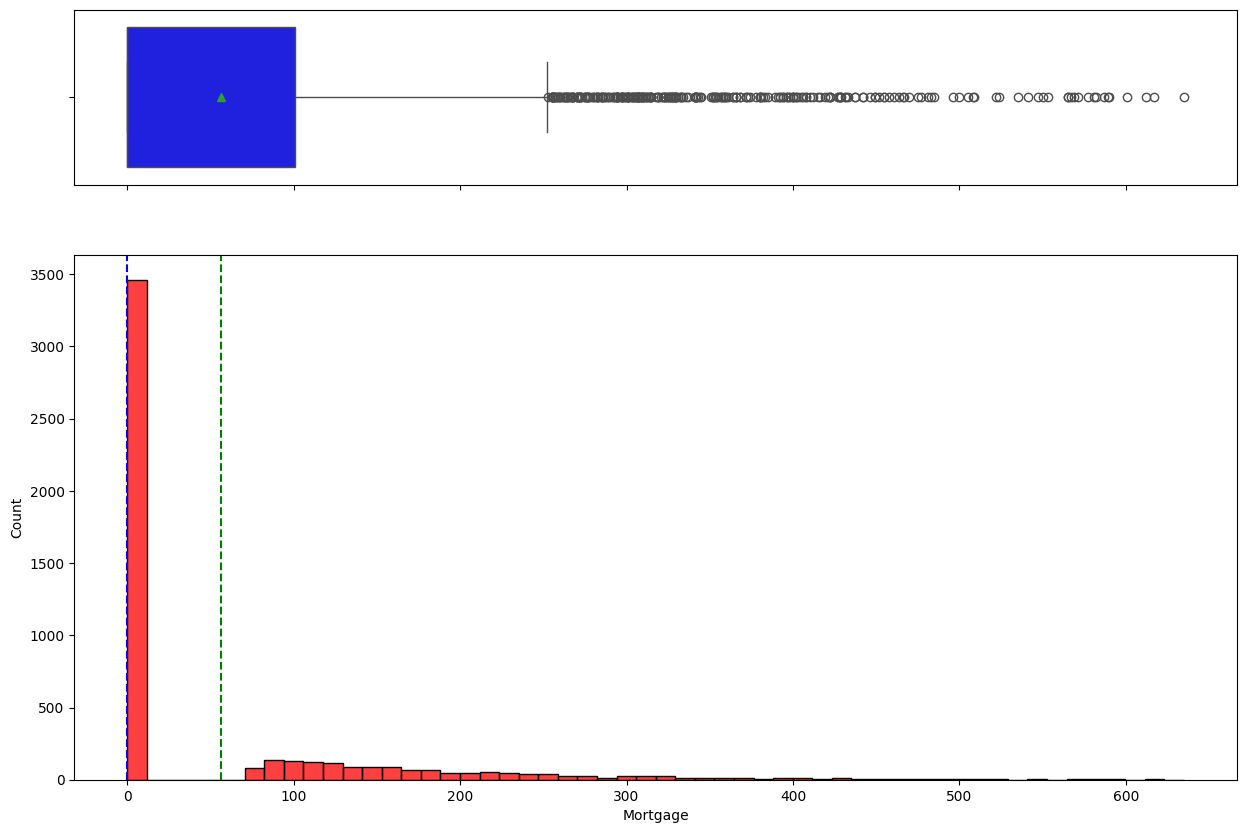

In [291]:
#histogram display
def draw_histogram_and_barplot(data, feature, figsize=(15,10)):

  #create the two axix for displaying box and histogram
  fig, (box_axis, hist_axis) = plt.subplots(nrows=2, ncols=1, sharex=True, gridspec_kw={"height_ratios": (0.25, 0.75)}, figsize = figsize)


  sns.boxplot(data=data, x= feature, ax = box_axis, showmeans=True, color='blue')

  sns.histplot(data=data, x=feature, ax = hist_axis, color='red')

  #show mean to the histogram
  hist_axis.axvline(data[feature].mean(), color="green", linestyle="--")

  #show median to the histogram
  hist_axis.axvline(data[feature].median(), color="blue", linestyle="--")

#draw for mortgage
draw_histogram_and_barplot(data, "Mortgage")

#### Observation
* mortgage distribution is right skewed with the average of 50k
* there are many high-end outliers present 300k to 600k

### 2. How many customers have credit cards?

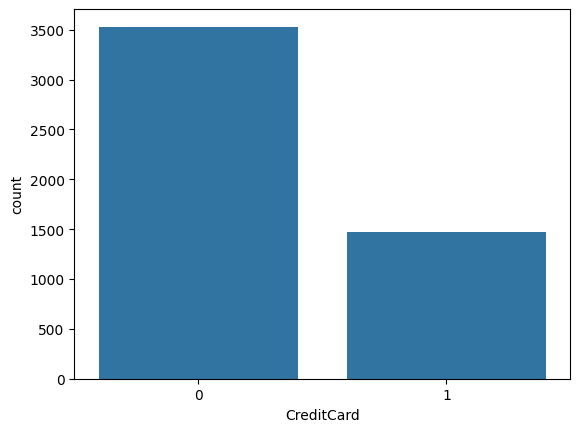

In [292]:
#how many customers have credit cards
cc_owners_count = (data['CreditCard'] > 0).sum()
cc_owners_count

#barplot

def barplot(data, feature, topN=None):
  #total = len(data[feature])
  count = data[feature].nunique()

  # plt.figure(figsize=(count + 2, 6))

  sns.countplot(data = data, x=feature)

barplot(data, 'CreditCard')

#### Observation
* there are around 1500(1470) customers who have credit card

### 3. What are the attributes that have a strong correlation with the target attribute (personal loan)?

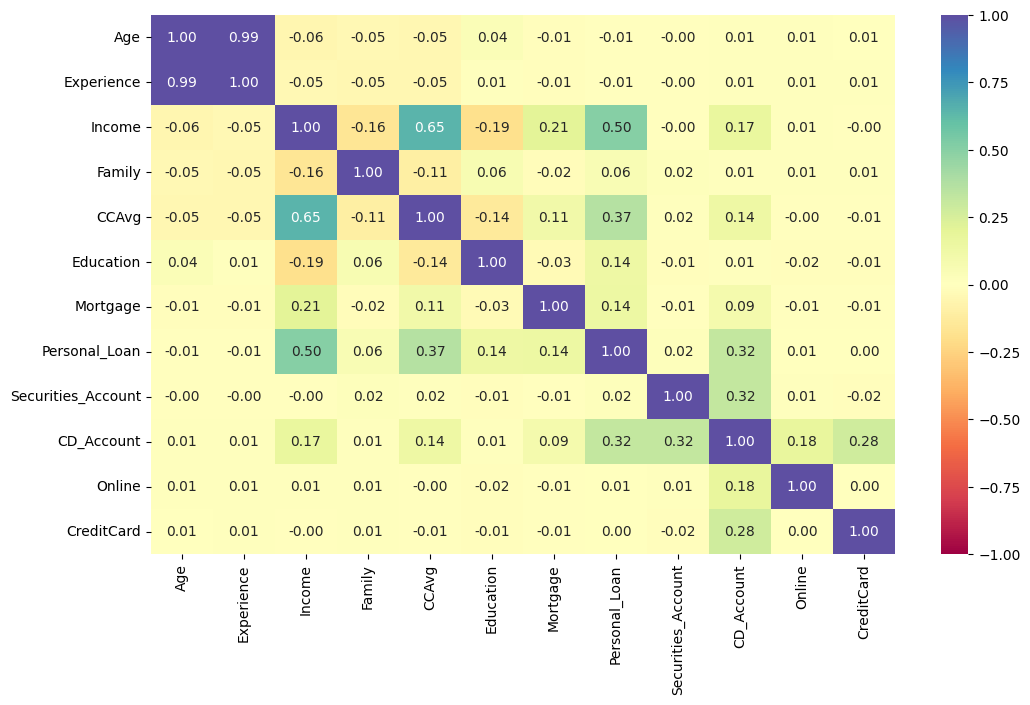

In [293]:
#heat map relationship with personal loab
cols_list = data.select_dtypes(include=np.number).columns.tolist()

plt.figure(figsize=(12, 7))
sns.heatmap(data[cols_list].corr(), annot=True, vmin=-1, vmax=1, fmt=".2f", cmap="Spectral")
plt.show()

#### Observation
* the attributes Income, CC_AVG, and CD_Account have the strongest relationship with personal loan

### 4. How does a customer's interest in purchasing a loan vary with their age?

In [294]:
### function to plot distributions wrt target

def distribution_plot_wrt_target(data, predictor, target):

    fig, axs = plt.subplots(2, 2, figsize=(12, 10)) #create a 2 rows by a two columns figure and set size

    target_uniq = data[target].unique() # identify unique target variable values 0/1 in our case

    axs[0, 0].set_title("Distribution of target for target=" + str(target_uniq[0])) #set first figure[0][0] in the first row title
    sns.histplot(data=data[data[target] == target_uniq[0]], x=predictor, ax=axs[0, 0],kde=True,stat="density",) # plot histogram of target variable 0 no personal loan taken


    axs[0, 1].set_title("Distribution of target for target=" + str(target_uniq[1])) #set second[0][1] figure title in the first row
    sns.histplot(data=data[data[target] == target_uniq[1]],x=predictor, ax=axs[0, 1],kde=True,stat="density",)# plot histogram of target variable 1 personal loan taken


    axs[1, 0].set_title("Boxplot w.r.t target") # set the first firgure in the second row title
    sns.boxplot(data=data,x=target, y=predictor, ax=axs[1, 0]) #plot the box plot of the target variable 0 personal loan not taken

    axs[1, 1].set_title("Boxplot (without outliers) w.r.t target")# set the second firgure in the second row title
    sns.boxplot(data=data,x=target,y=predictor,ax=axs[1, 1], showfliers=False)#plot the box plot of the target variable 1 personal loan not taken

    plt.tight_layout()
    plt.show()

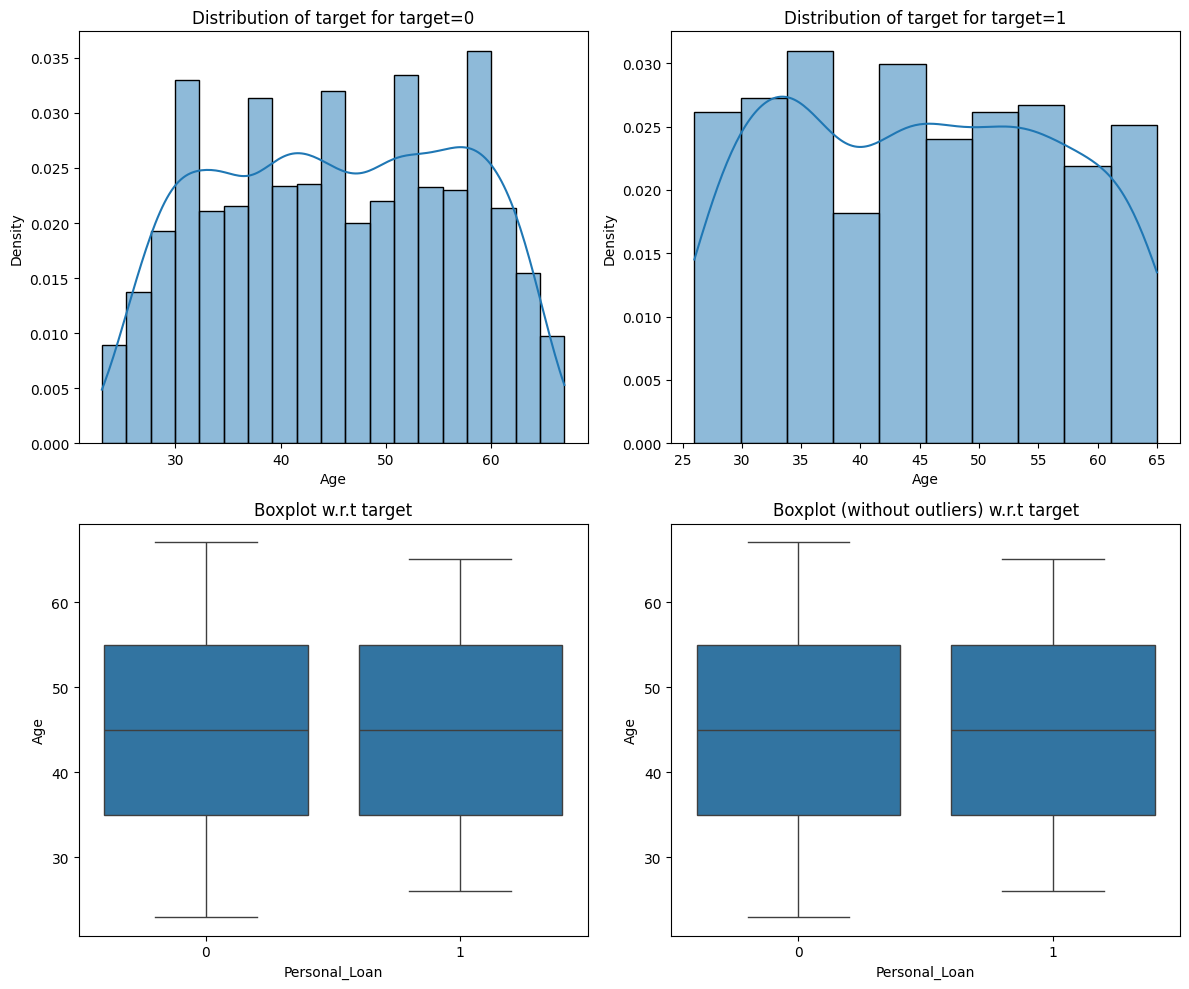

In [295]:
#Age vs Personal Loan
distribution_plot_wrt_target(data, "Age", "Personal_Loan")

#### Observation :
- age is not a big factor for determining if loan is taken or not
- there's an overlap between taken/not taken age groups


### 5. How does a customer's interest in purchasing a loan vary with their education?

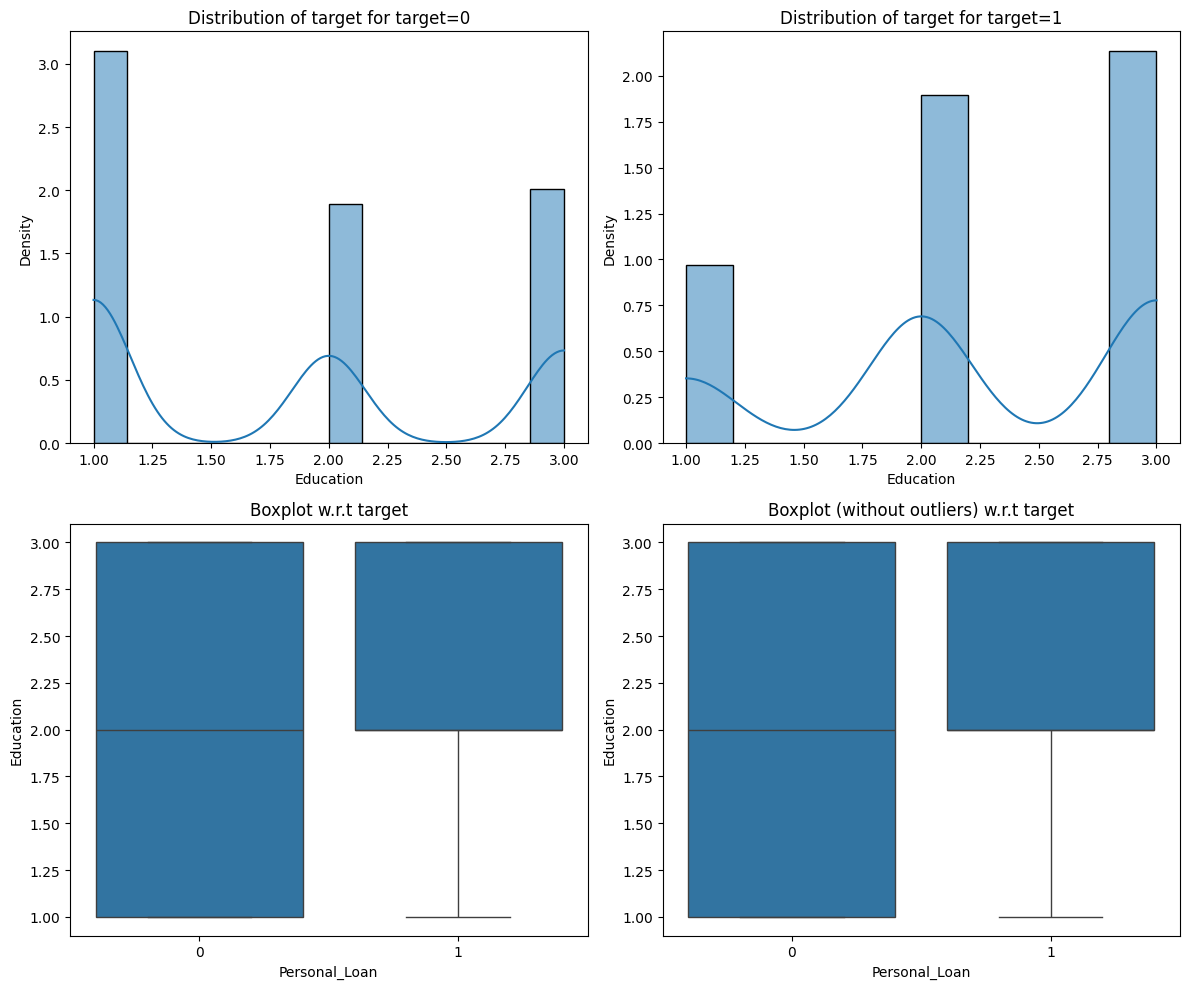

In [296]:
#5. Education vs Personal Loan
distribution_plot_wrt_target(data, "Education", "Personal_Loan")

#### Observation :
- most loan taker have education level of 2 and 3
- most customers with education level of 1 don't take loan
- education is a big factor

## Data Preprocessing

* Missing value treatment
* Feature engineering (if needed)
* Outlier detection and treatment (if needed)
* Preparing data for modeling
* Any other preprocessing steps (if needed)

### Missing value treatment

In [297]:
# Missing value treatment
data.isnull().sum()

,0
Age,0
Experience,0
Income,0
Family,0
CCAvg,0
Education,0
Mortgage,0
Personal_Loan,0
Securities_Account,0
CD_Account,0


#### Observation
- there's no missing value

### Feature engineering (if needed)

In [298]:
#Feature engineering (if needed)
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Age                 5000 non-null   int64  
 1   Experience          5000 non-null   int64  
 2   Income              5000 non-null   int64  
 3   Family              5000 non-null   int64  
 4   CCAvg               5000 non-null   float64
 5   Education           5000 non-null   int64  
 6   Mortgage            5000 non-null   int64  
 7   Personal_Loan       5000 non-null   int64  
 8   Securities_Account  5000 non-null   int64  
 9   CD_Account          5000 non-null   int64  
 10  Online              5000 non-null   int64  
 11  CreditCard          5000 non-null   int64  
dtypes: float64(1), int64(11)
memory usage: 468.9 KB


#### Observation :
- all the columns are continous variables, there's no need for encoding categorical variables

### Outlier detection and treatment (if needed)

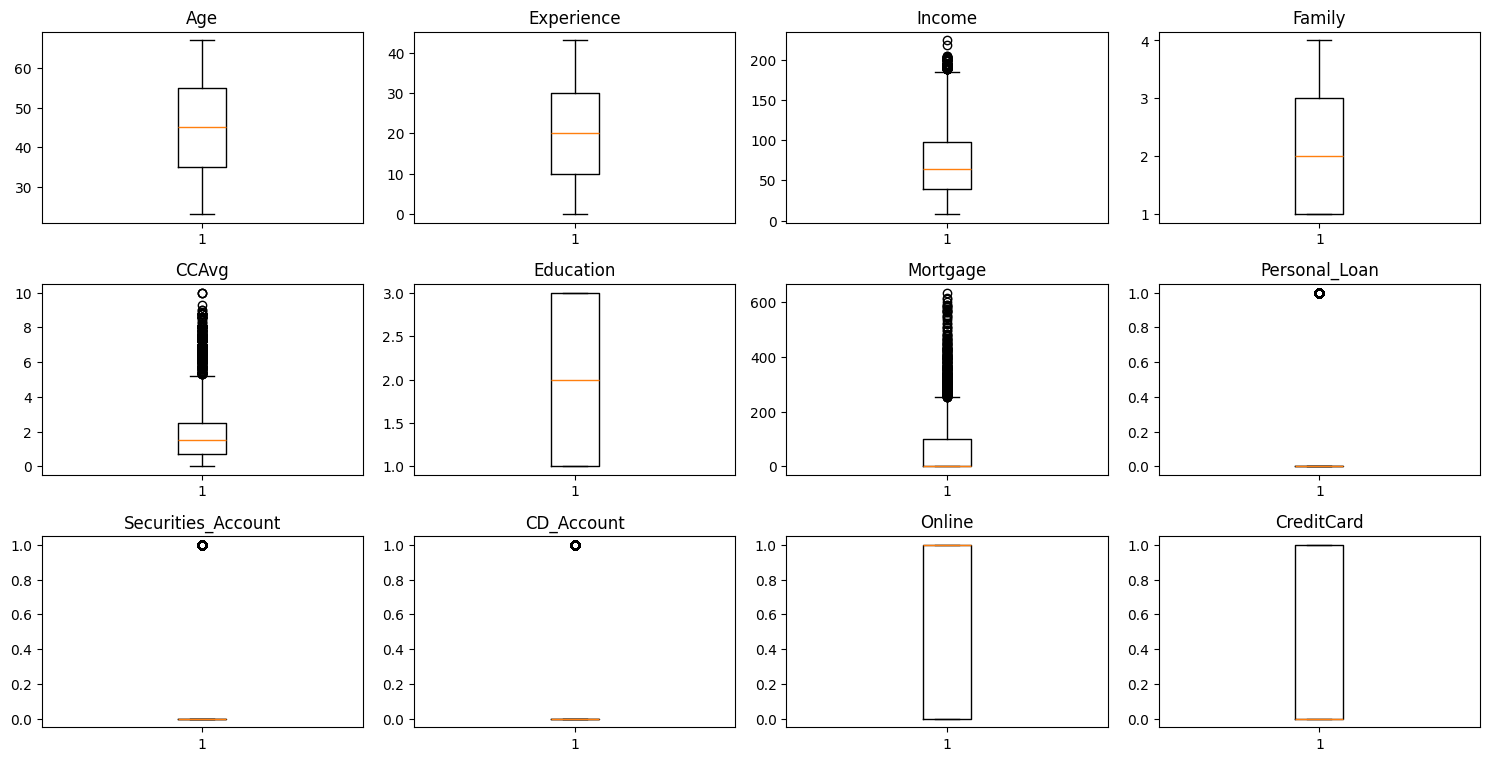

In [299]:
#Outlier detection and treatment (if needed)

data['Experience'] = data['Experience'].apply(lambda x: 0 if x < 0 else x)

columns = data.select_dtypes(include= np.number).columns.tolist()
#data.columns.tolist()

plt.figure(figsize=(15,10))
for (index, feature) in enumerate(columns):
  plt.subplot(4,4, index+1)
  plt.boxplot(data[feature], whis=1.5)
  plt.tight_layout()
  plt.title(feature)

plt.show()



#### Observations
- colums with outlier values are `Income` `CC_AVg` `Mortgage`
- feature `Experience` has invalid negative values that needs to be cleaned so replaced all cell values which have less than 0 value with 0

### Preparing data for modeling

In [300]:
#Preparing data for modeling
X = data.drop('Personal_Loan', axis=1)
y = data['Personal_Loan']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=1
)

X_test.head()

,Age,Experience,Income,Family,CCAvg,Education,Mortgage,Securities_Account,CD_Account,Online,CreditCard
2764,31,5,84,1,2.9,3,105,0,0,0,1
4767,35,9,45,3,0.9,1,101,1,0,0,0
3814,34,9,35,3,1.3,1,0,0,0,0,0
3499,49,23,114,1,0.3,1,286,0,0,1,0
2735,36,12,70,3,2.6,2,165,0,0,1,0


In [301]:
print("Shape of Training set : ", X_train.shape)
print("Shape of test set : ", X_test.shape)
print("Percentage of classes in training set:")
print(y_train.value_counts(normalize=True))
print("Percentage of classes in test set:")
print(y_test.value_counts(normalize=True))

Shape of Training set :  (3500, 11)
Shape of test set :  (1500, 11)
Percentage of classes in training set:
Personal_Loan
0    0.905429
1    0.094571
Name: proportion, dtype: float64
Percentage of classes in test set:
Personal_Loan
0    0.900667
1    0.099333
Name: proportion, dtype: float64


#### Observation
- the split shows that 90.5% of the training samples are 0(loan not taken)
- and 9.5% are loan taken(1)

- the split shows that 90% of the test samples are 0(loan not taken)
- and 10% are loan taken(1)

- which is acceptable for inbalanced data

## Model Building

### Model Evaluation Criterion

Model can make false prediction as FN (false negative) and FP (false positive)
- if model predicts FP then we will send a campaign offer for a personal loan but user will not take the loan
-if model predicts FN then we won't send the campaign but infact the user is a perpective cleint for a personal loan

- so we need to decrease our FN by having low recall


### Decision Tree (default)

In [302]:
# model performance reusable method
# model is the classification model model = Classification(params .....)
# predictors is X_train/X_test
# target is y_train/y_test
def model_performance_classification(model, predictors, target):
  predicted = model.predict(predictors)

  accuracy = accuracy_score(target, predicted)
  precision = precision_score(target, predicted)
  recall = recall_score(target, predicted)
  f1 = f1_score(target, predicted)

  return pd.DataFrame({"accuracy": accuracy, "precision": precision, "recall": recall, "f1_score": f1}, index=[0],)


In [303]:
def confusion_matrix_sklearn(model, predictors, target):
    y_pred = model.predict(predictors)
    confusion_mx = sk_confusion_matrix(target, y_pred)   # (y_true, y_pred)

    labels = np.asarray(
        [
            ["{0:0.0f}".format(item) + "\n{0:.2%}".format(item / confusion_mx.sum())]
            for item in confusion_mx.flatten()
        ]
    ).reshape(2, 2)

    plt.figure(figsize=(6, 4))
    sns.heatmap(confusion_mx, annot=labels, fmt="")
    plt.ylabel("True label")
    plt.xlabel("Predicted label")
    plt.show()

In [304]:
#model zero with no parameter tunning
model0 = DecisionTreeClassifier(random_state=1)
model0.fit(X_train, y_train)

DecisionTreeClassifier(random_state=1)

In [305]:
#model 0 performance
model0_performance = model_performance_classification(model0, X_train, y_train)
model0_performance

,accuracy,precision,recall,f1_score
0,1.0,1.0,1.0,1.0


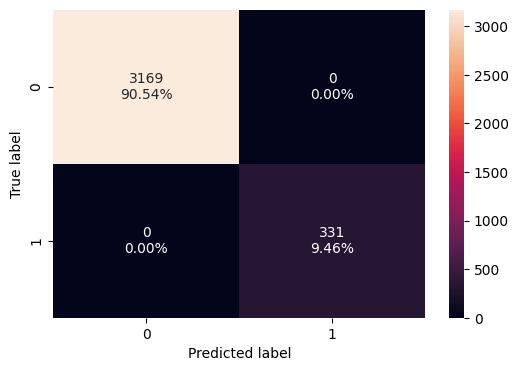

In [306]:
#model0 confusion matrix
confusion_matrix_sklearn(model0, X_train, y_train)

#### Observation
- model is doing well in the training set with 0 FP and FN
- model also has 1 as the accuracy/recall/precision and f1_score

In [307]:
#model0 performance in the test data
model0_test_performance = model_performance_classification(model0, X_test, y_test)
model0_test_performance

,accuracy,precision,recall,f1_score
0,0.98,0.910345,0.885906,0.897959


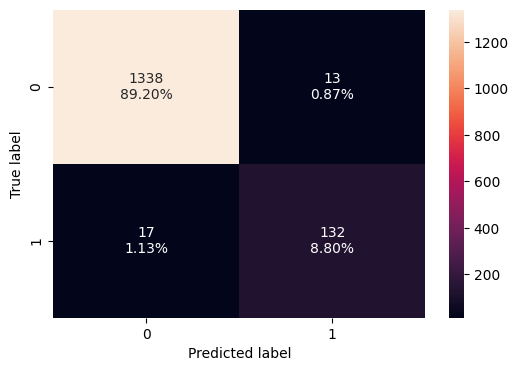

In [308]:
#model0 confusion matrix
confusion_matrix_sklearn(model0, X_test, y_test)

#### Observation
- model predicted 1% as false negative and 1.47 as false positive
- model predicted 88.9% as true negative and 8.6% as true postive
- model has a 97% accuracy and 89% recall 85% precision


## Model Performance Improvement

### Decision Tree (with class_weights)

#### since our data shows 90% of the last loan campaign were not accepted by customers the decision tree model will be biased towards the dominant class

- adjusting `class_weight`=`balanced` will make the weight to be inversely proportional to the class frequencies in the data set

In [309]:
#model one
model1 = DecisionTreeClassifier(random_state=1, class_weight="balanced")
model1.fit(X_train, y_train)

DecisionTreeClassifier(class_weight='balanced', random_state=1)

In [310]:
#model one performance on training data set
model1_performance = model_performance_classification(model1, X_train, y_train)
model1_performance

,accuracy,precision,recall,f1_score
0,1.0,1.0,1.0,1.0


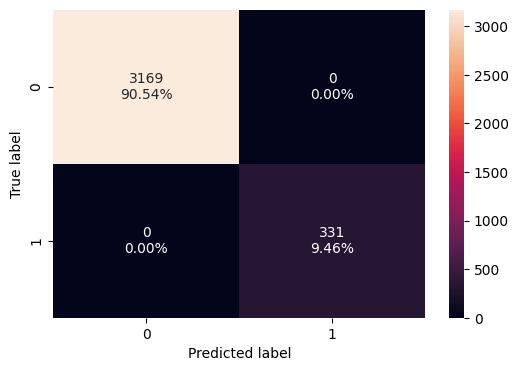

In [311]:
#model one confusion matrix
confusion_matrix_sklearn(model1, X_train, y_train)

#### observation
- model is fitting perfectly on the training set
- no errors

In [312]:
#model one performance on the test data set
model1_test_performance = model_performance_classification(model1, X_test, y_test)
model1_test_performance

,accuracy,precision,recall,f1_score
0,0.974667,0.882759,0.85906,0.870748


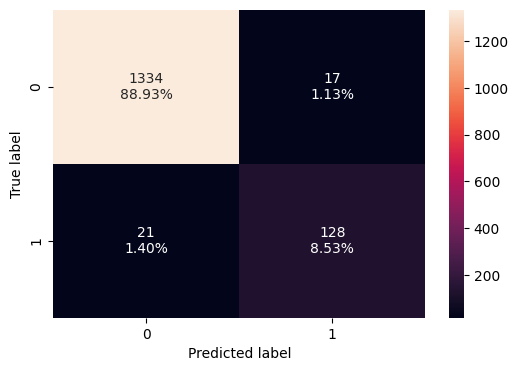

In [313]:
#model one confusion matrix
confusion_matrix_sklearn(model1, X_test, y_test)

#### Observation
- there's a slight difference in model's performance in training set vs test set
- test has a 97% accuracy and a 90% precision which is okay
- model shows more FP and FN after class_weight is set to balanced
- model might be still be overfitting in the training data set

### pre-pruning the decision tree

In [314]:
# Define the parameters of the tree to iterate over
# Maximum depth of the tree
max_depth_values = [3, 4, 6, 8, 10, None]  # Use fixed values instead of using arange for large steps or None

# Maximum number of leaf nodes
max_leaf_nodes_values = [10, 25, 50, None]

# Minimum number of samples required to split an internal node
min_samples_split_values = [2, 5, 10, 20]


best_model = None # best decision tree with all tuned params

best_recall_score = 0.0 # the higher the recall score the better
performance = None

best_score_diff_train_vs_test = float('inf')  # the lower the differene between training and test performace the better

for max_depth in max_depth_values:
  for max_leaf in max_leaf_nodes_values:
    for min_sample in min_samples_split_values:

      model = DecisionTreeClassifier(max_depth=max_depth,max_leaf_nodes=max_leaf,min_samples_split=min_sample, class_weight='balanced',random_state=1)
      model.fit(X_train, y_train)

      train_predicted = model.predict(X_train)
      test_predicted = model.predict(X_test)

      train_recall_score = recall_score(y_train, train_predicted)
      test_recall_score = recall_score(y_test, test_predicted)

      test_precision = precision_score(y_test, test_predicted)
      test_accuracy = accuracy_score(y_test, test_predicted)
      test_f1_score = f1_score(y_test, test_predicted)

      score_diff = abs(train_recall_score - test_recall_score)

      if(score_diff < best_score_diff_train_vs_test) & (test_recall_score > best_recall_score):
        best_score_diff_train_vs_test = score_diff
        performance = pd.DataFrame({"accuracy": test_accuracy, "precision": test_precision, "recall": test_recall_score, "f1_score": test_f1_score}, index=[0],)
        best_model = model


print("Best parameters found:")
print(f"Max depth: {best_model.max_depth}")
print(f"Max leaf nodes: {best_model.max_leaf_nodes}")
print(f"Min samples split: {best_model.min_samples_split}")
print("Model : ", best_model)
print(performance)

Best parameters found:
Max depth: 6
Max leaf nodes: 10
Min samples split: 2
Model :  DecisionTreeClassifier(class_weight='balanced', max_depth=6, max_leaf_nodes=10,
                       random_state=1)
   accuracy  precision    recall  f1_score
0     0.954   0.688679  0.979866  0.808864


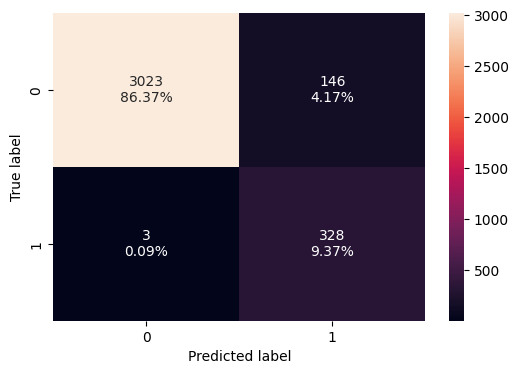

In [315]:
#confusion matrix of the best model on a training data set
confusion_matrix_sklearn(best_model, X_train, y_train)

In [316]:
#model performance in training set
best_model_performance_train = model_performance_classification(best_model, X_train, y_train)
best_model_performance_train

,accuracy,precision,recall,f1_score
0,0.957429,0.691983,0.990937,0.814907


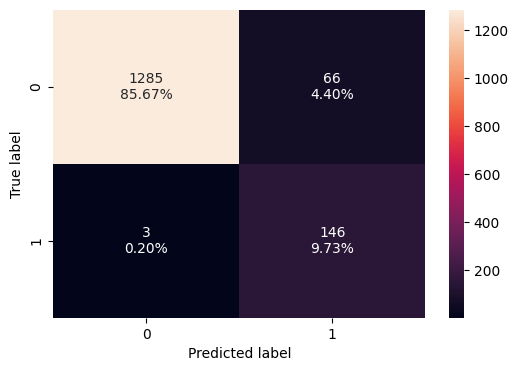

In [317]:
##confusion matrix of the best model on a test data set
confusion_matrix_sklearn(best_model, X_test, y_test)

In [318]:
#model performance in test set
best_model_performance_test = model_performance_classification(best_model, X_test, y_test)
best_model_performance_test

,accuracy,precision,recall,f1_score
0,0.954,0.688679,0.979866,0.808864


#### Observation
- model is able to generalized pretty well both on the training set and test set with recall value of 0.97 with zero false negatives

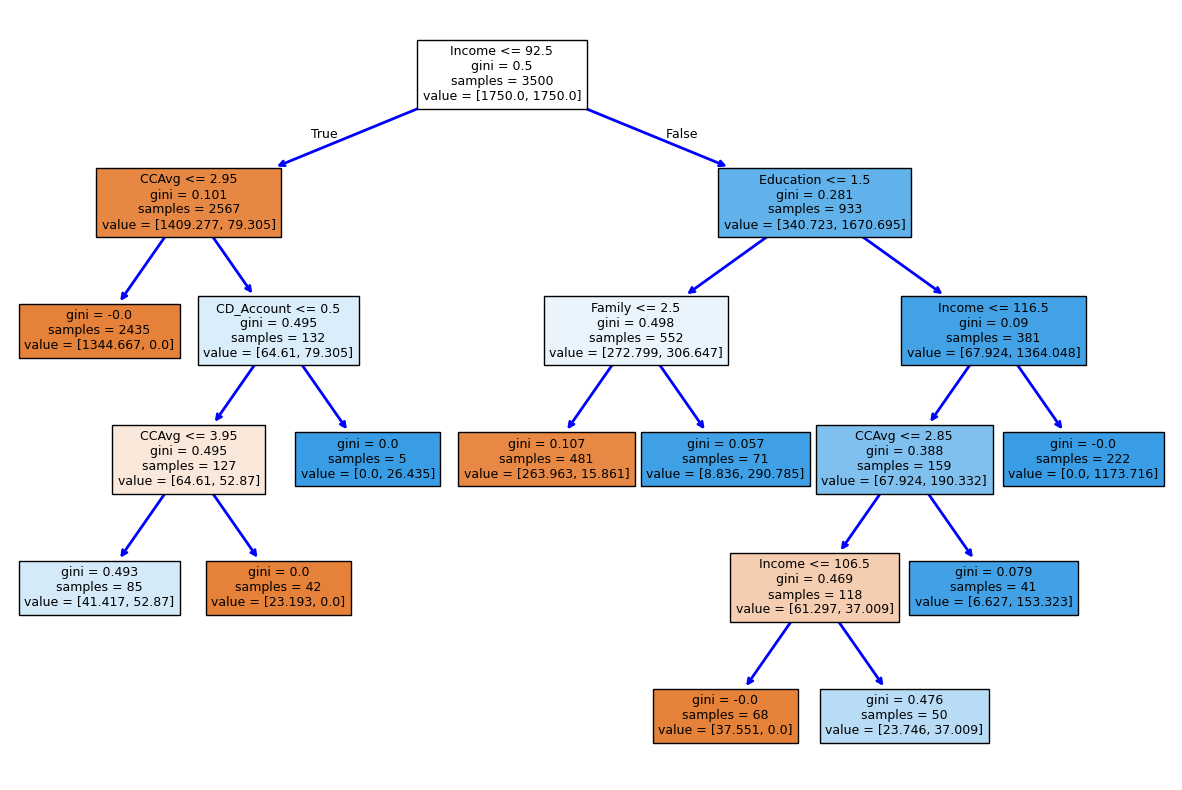

In [319]:
#feature importances
features = X_train.columns.tolist()
# features

importances = best_model.feature_importances_
# importances

figure = plt.figure(figsize = (15,10))
output = tree.plot_tree(best_model, feature_names=features, filled=True, fontsize=9, node_ids=False, class_names=None)

for out in output:
  arrow= out.arrow_patch
  if(arrow is not None):
    arrow.set_edgecolor("blue")
    arrow.set_linewidth(2)

plt.show()


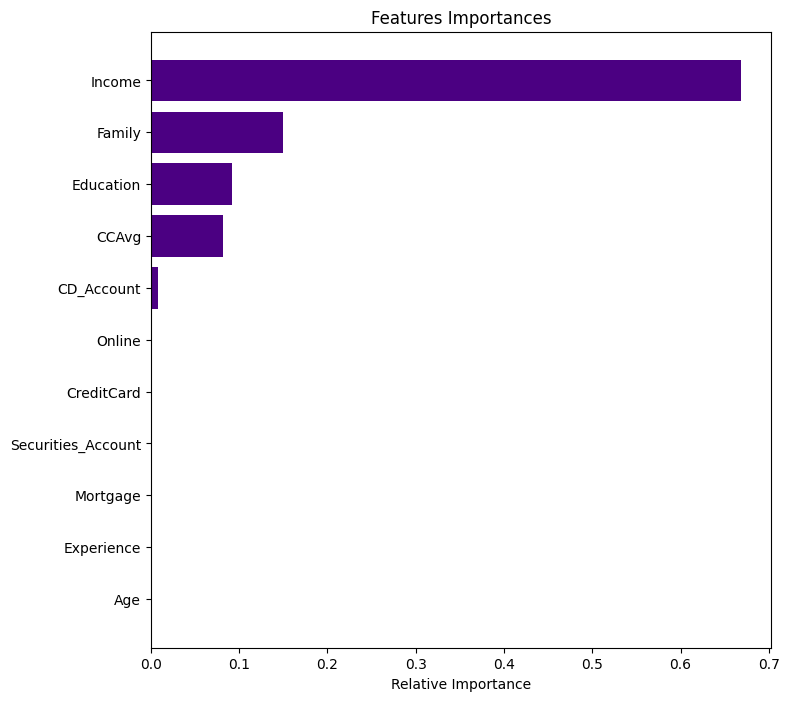

In [320]:
#model importances

indices = np.argsort(importances)
# indices

importances = best_model.feature_importances_
indices = np.argsort(importances)

plt.figure(figsize=(8,8))
plt.title("Features Importances")
plt.barh(range(len(indices)), importances[indices], color="indigo", align="center")
plt.yticks(range(len(indices)), [features[i] for i in indices])
plt.xlabel("Relative Importance")
plt.show()

#### Observation
- `Income` `Family` `Education` and `CC_Average` are the most important features used by the model for classification
- `Income` is the most important feature
- `Online` `Credit Card` `Securities Account` `Mortgage` `Experience` and `Age` are the lease important features

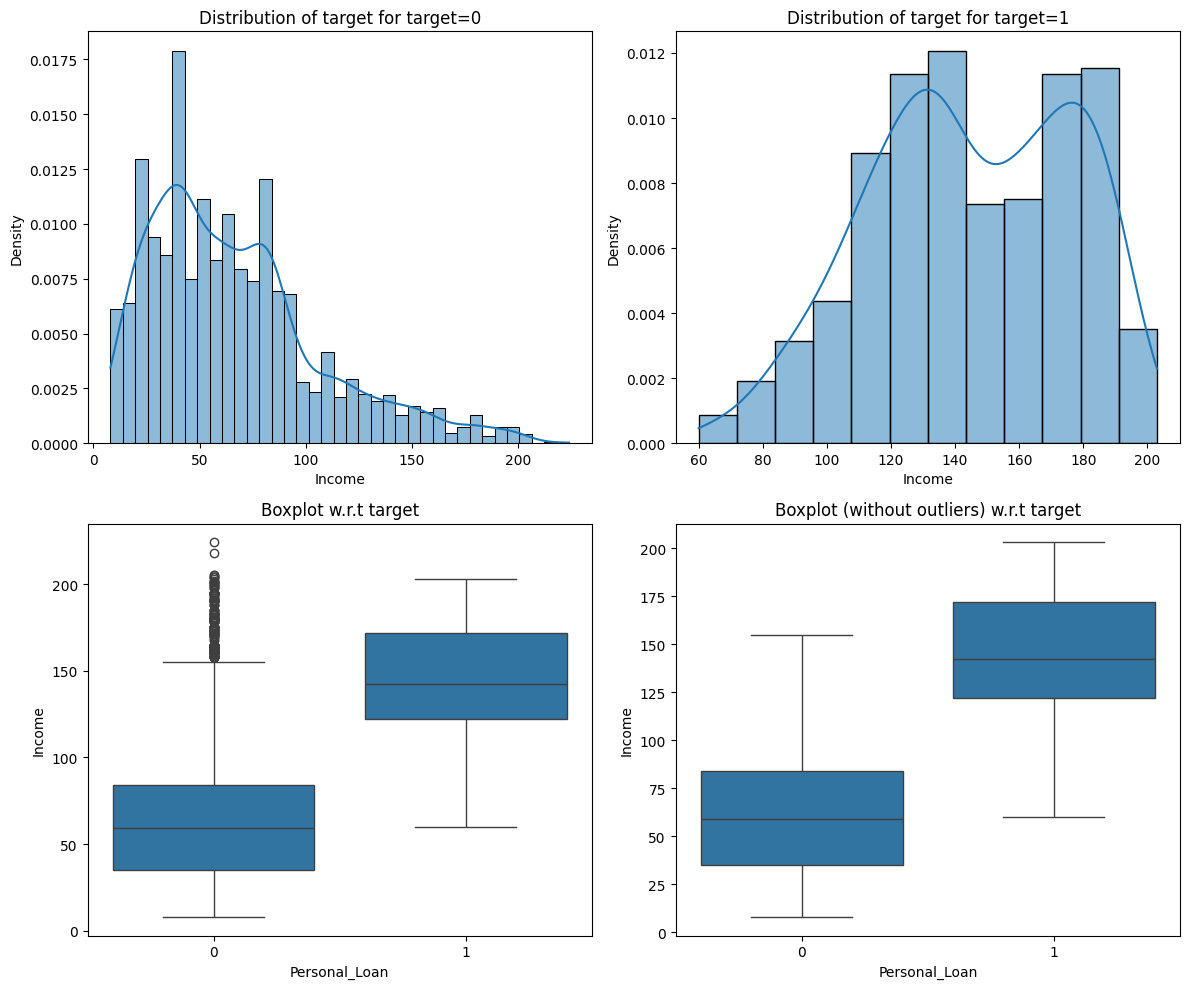

In [321]:
#Income vs Personal Loan
distribution_plot_wrt_target(data, "Income", "Personal_Loan")

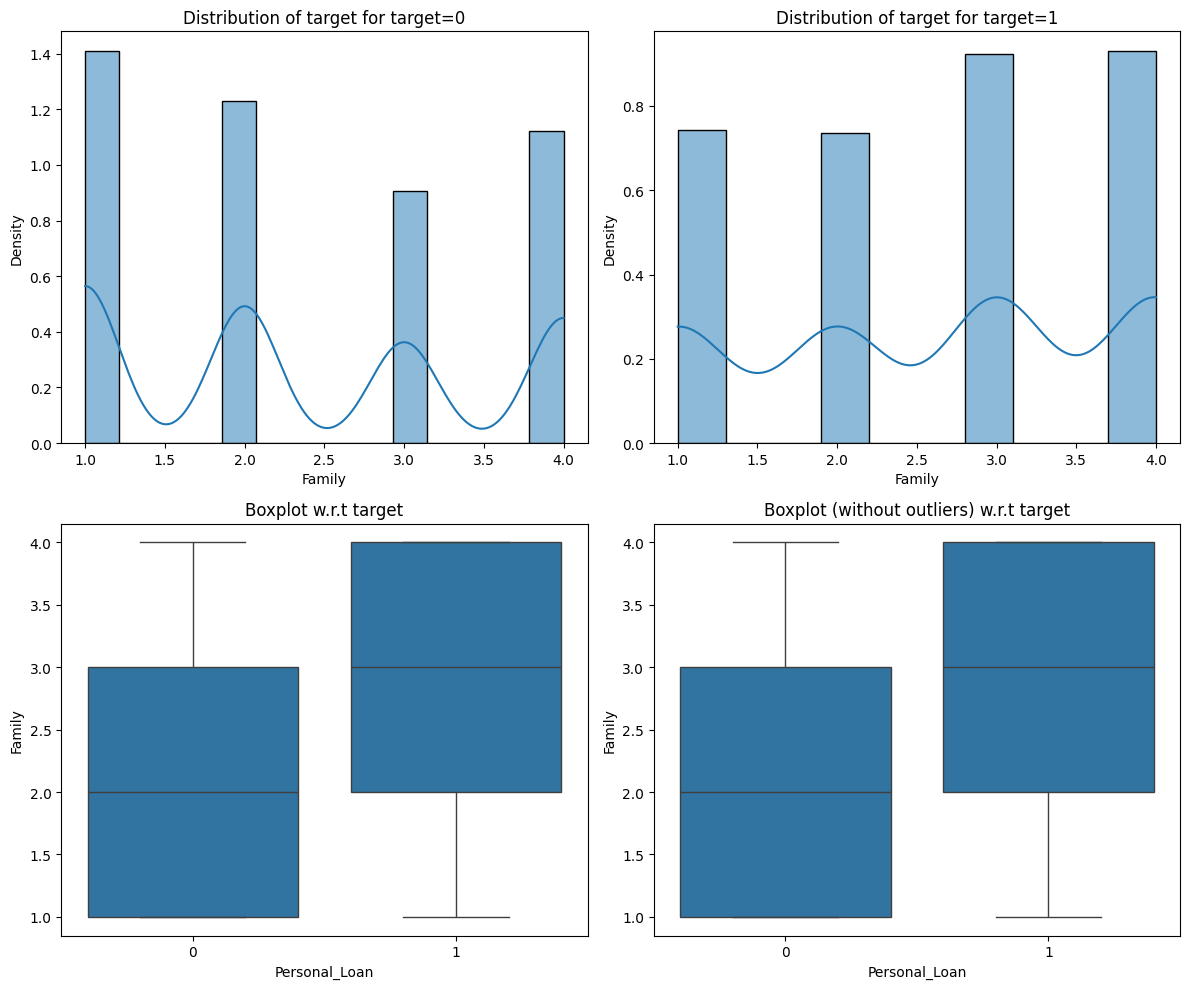

In [322]:
#Family vs Personal Loan
distribution_plot_wrt_target(data, "Family", "Personal_Loan")

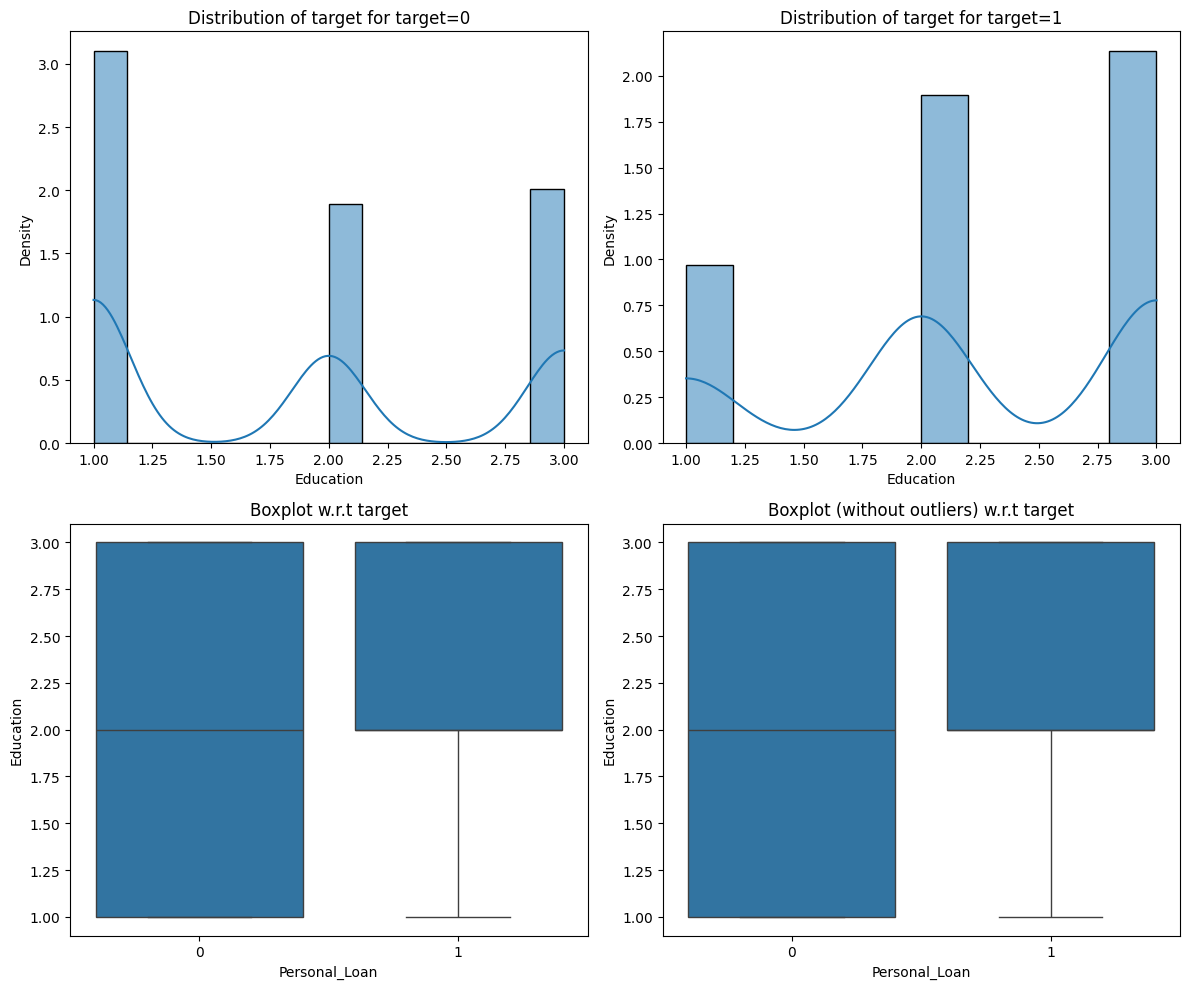

In [323]:
#Family vs Personal Loan
distribution_plot_wrt_target(data, "Education", "Personal_Loan")

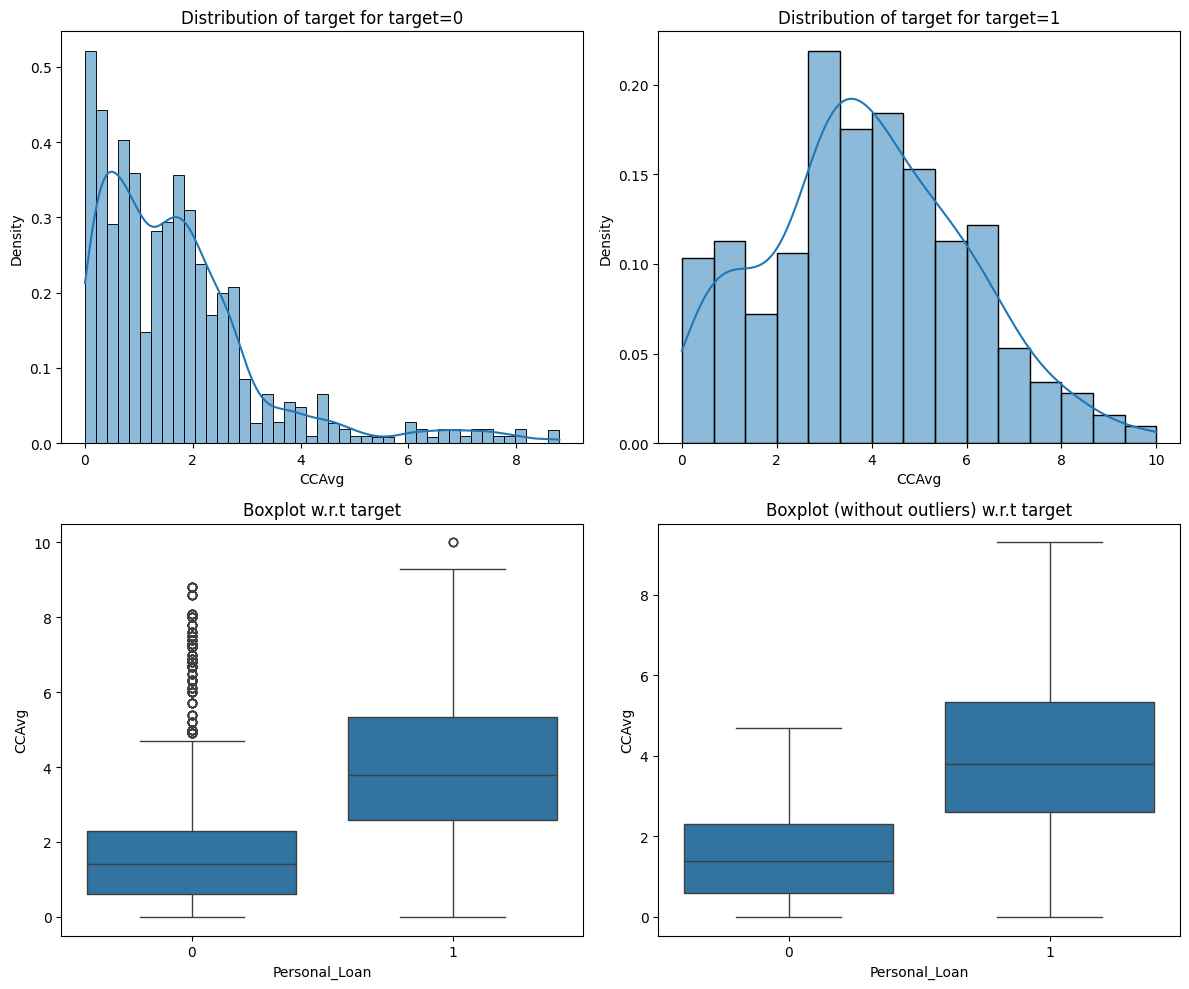

In [324]:
#Family vs Personal Loan
distribution_plot_wrt_target(data, "CCAvg", "Personal_Loan")

### Decision Tree (Post pruning)

In [325]:
#### Decision Tree (Post pruning)
clf = DecisionTreeClassifier(random_state=1, class_weight="balanced")
path = clf.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas, impurities = abs(path.ccp_alphas), path.impurities

In [326]:
pd.DataFrame(path)

,ccp_alphas,impurities
0,0.000000e+00,-1.940128e-15
1,3.853725e-19,-1.939743e-15
2,3.853725e-19,-1.939357e-15
3,3.853725e-19,-1.938972e-15
4,4.729571e-19,-1.938499e-15
5,5.255079e-19,-1.937974e-15
6,7.006772e-19,-1.937273e-15
7,1.051016e-18,-1.936222e-15
8,1.257806e-17,-1.923644e-15
9,1.524700e-04,3.049400e-04


In [327]:
#train a decision tree using the effective alphas. The last value in ccp_alphas is the alpha value that prunes the whole tree, leaving the tree, clfs[-1]
clfs = []
for ccp_alpha in ccp_alphas:
    clf = DecisionTreeClassifier(
        random_state=1, ccp_alpha=ccp_alpha, class_weight="balanced"
    )
    clf.fit(X_train, y_train)
    clfs.append(clf)
print(
    "Number of nodes in the last tree is: {} with ccp_alpha: {}".format(
        clfs[-1].tree_.node_count, ccp_alphas[-1]
    )
)

Number of nodes in the last tree is: 1 with ccp_alpha: 0.29537927599923264


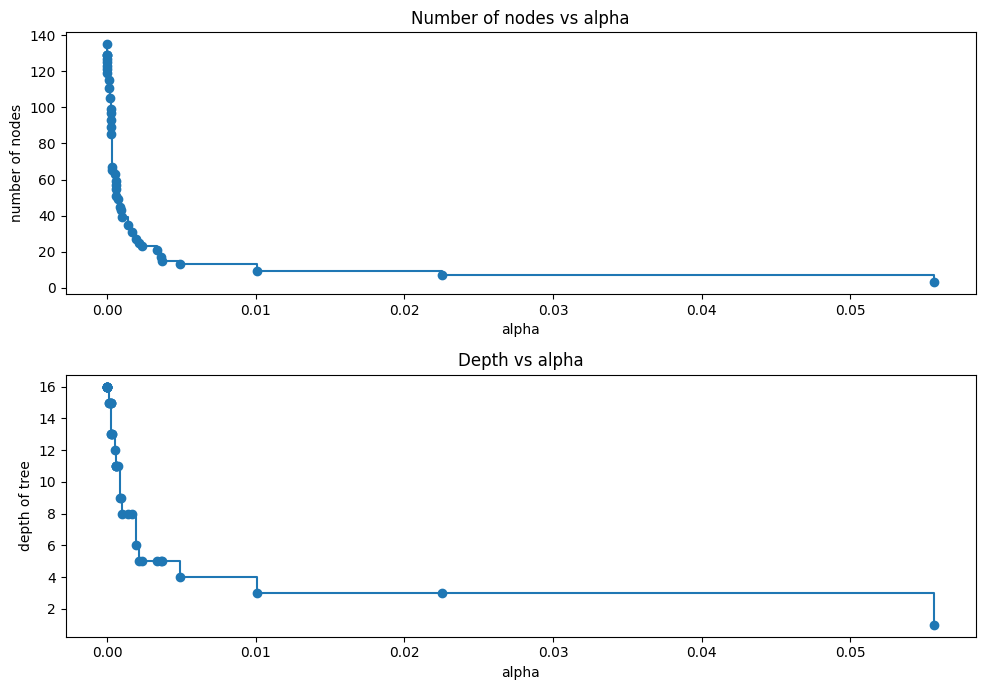

In [328]:
clfs = clfs[:-1]
ccp_alphas = ccp_alphas[:-1]

node_counts = [clf.tree_.node_count for clf in clfs]
depth = [clf.tree_.max_depth for clf in clfs]
fig, ax = plt.subplots(2, 1, figsize=(10, 7))
ax[0].plot(ccp_alphas, node_counts, marker="o", drawstyle="steps-post")
ax[0].set_xlabel("alpha")
ax[0].set_ylabel("number of nodes")
ax[0].set_title("Number of nodes vs alpha")
ax[1].plot(ccp_alphas, depth, marker="o", drawstyle="steps-post")
ax[1].set_xlabel("alpha")
ax[1].set_ylabel("depth of tree")
ax[1].set_title("Depth vs alpha")
fig.tight_layout()

In [329]:
recall_train = []
for clf in clfs:
    pred_train = clf.predict(X_train)
    values_train = recall_score(y_train, pred_train)
    recall_train.append(values_train)

In [330]:
recall_test = []
for clf in clfs:
    pred_test = clf.predict(X_test)
    values_test = recall_score(y_test, pred_test)
    recall_test.append(values_test)

In [331]:
train_scores = [clf.score(X_train, y_train) for clf in clfs]
test_scores = [clf.score(X_test, y_test) for clf in clfs]

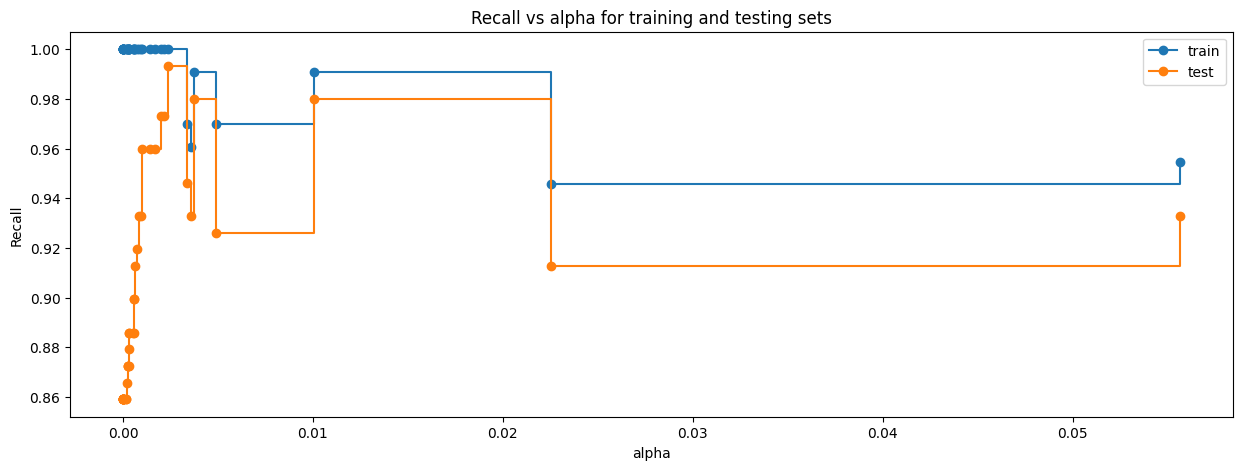

In [332]:
fig, ax = plt.subplots(figsize=(15, 5))
ax.set_xlabel("alpha")
ax.set_ylabel("Recall")
ax.set_title("Recall vs alpha for training and testing sets")
ax.plot(
    ccp_alphas, recall_train, marker="o", label="train", drawstyle="steps-post",
)
ax.plot(ccp_alphas, recall_test, marker="o", label="test", drawstyle="steps-post")
ax.legend()
plt.show()

In [333]:
# creating the model where we get highest train and test recall
index_best_model = np.argmax(recall_test)
best_model = clfs[index_best_model]
print(best_model)

DecisionTreeClassifier(ccp_alpha=np.float64(0.002375808619774645),
                       class_weight='balanced', random_state=1)


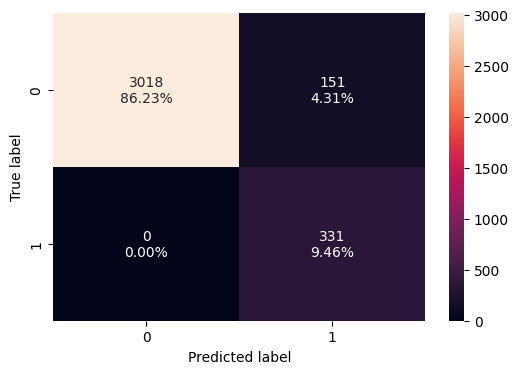

In [334]:
model4 = best_model
confusion_matrix_sklearn(model4, X_train, y_train)

In [335]:
decision_tree_post_perf_train = model_performance_classification(
    model4, X_train, y_train
)
decision_tree_post_perf_train

,accuracy,precision,recall,f1_score
0,0.956857,0.686722,1.0,0.814268


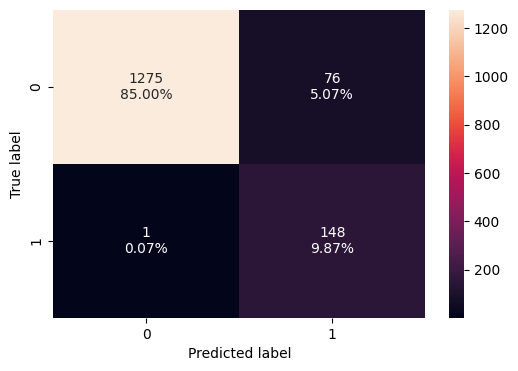

In [336]:
confusion_matrix_sklearn(model4, X_test, y_test)

In [337]:
decision_tree_post_test = model_performance_classification(
    model4, X_test, y_test
)
decision_tree_post_test

,accuracy,precision,recall,f1_score
0,0.948667,0.660714,0.993289,0.793566


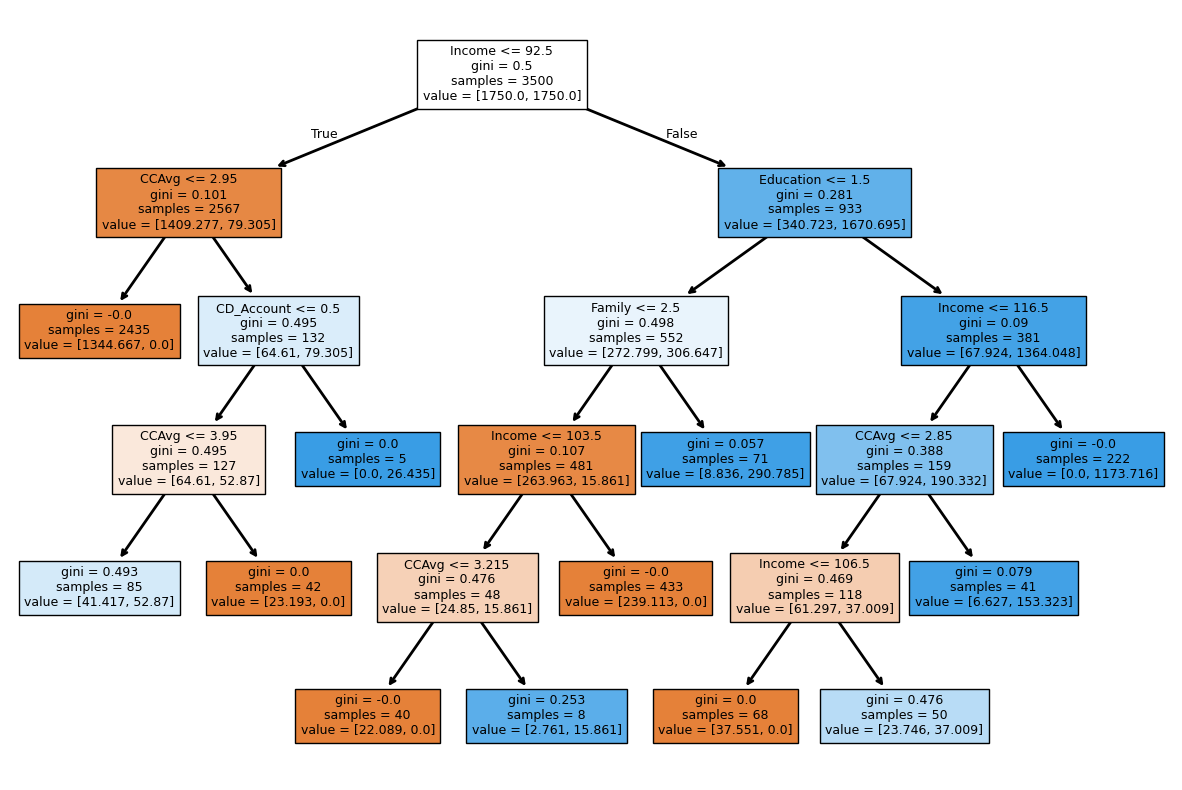

In [338]:
plt.figure(figsize = (15,10))

out = tree.plot_tree(
    model4,
    feature_names=features,
    filled=True,
    fontsize=9,
    node_ids=False,
    class_names=None,
)
for o in out:
    arrow = o.arrow_patch
    if arrow is not None:
        arrow.set_edgecolor("black")
        arrow.set_linewidth(2)
plt.show()

In [339]:
# Text report showing the rules of a decision tree -

print(tree.export_text(model4, feature_names=features, show_weights=True))

|--- Income <= 92.50
|   |--- CCAvg <= 2.95
|   |   |--- weights: [1344.67, 0.00] class: 0
|   |--- CCAvg >  2.95
|   |   |--- CD_Account <= 0.50
|   |   |   |--- CCAvg <= 3.95
|   |   |   |   |--- weights: [41.42, 52.87] class: 1
|   |   |   |--- CCAvg >  3.95
|   |   |   |   |--- weights: [23.19, 0.00] class: 0
|   |   |--- CD_Account >  0.50
|   |   |   |--- weights: [0.00, 26.44] class: 1
|--- Income >  92.50
|   |--- Education <= 1.50
|   |   |--- Family <= 2.50
|   |   |   |--- Income <= 103.50
|   |   |   |   |--- CCAvg <= 3.21
|   |   |   |   |   |--- weights: [22.09, 0.00] class: 0
|   |   |   |   |--- CCAvg >  3.21
|   |   |   |   |   |--- weights: [2.76, 15.86] class: 1
|   |   |   |--- Income >  103.50
|   |   |   |   |--- weights: [239.11, 0.00] class: 0
|   |   |--- Family >  2.50
|   |   |   |--- weights: [8.84, 290.79] class: 1
|   |--- Education >  1.50
|   |   |--- Income <= 116.50
|   |   |   |--- CCAvg <= 2.85
|   |   |   |   |--- Income <= 106.50
|   |   |   |   | 

In [340]:
importances = model4.feature_importances_
indices = np.argsort(importances)

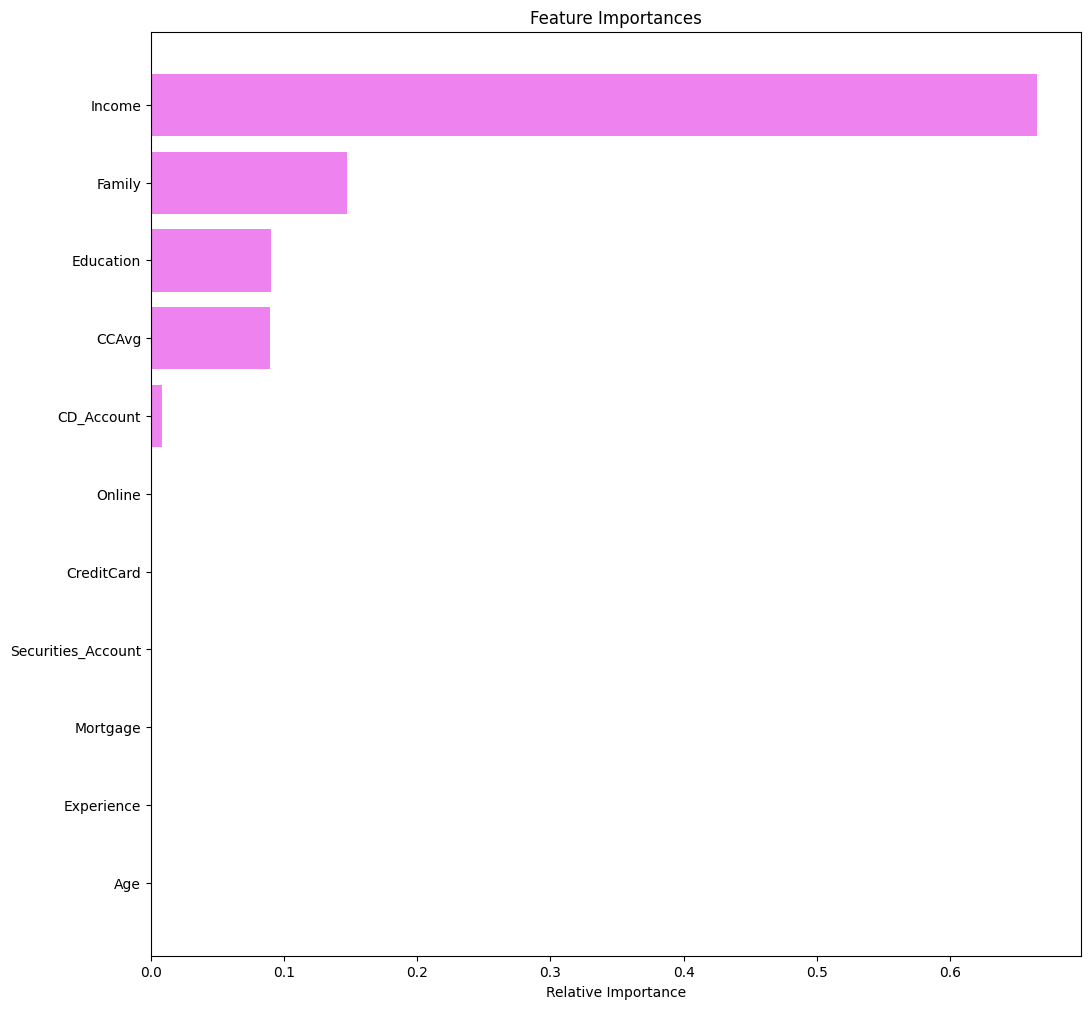

In [341]:
plt.figure(figsize=(12, 12))
plt.title("Feature Importances")
plt.barh(range(len(indices)), importances[indices], color="violet", align="center")
plt.yticks(range(len(indices)), [features[i] for i in indices])
plt.xlabel("Relative Importance")
plt.show()

## Model Performance Comparison and Final Model Selection

In [342]:
## training performance comparison

models_train_comp_df = pd.concat(
    [
        model0_performance.T,
        model1_performance.T,
        best_model_performance_train.T,
        decision_tree_post_perf_train.T,
    ],
    axis=1,
)
models_train_comp_df.columns = [
    "Decision Tree (sklearn default)",
    "Decision Tree with class_weight",
    "Decision Tree (Pre-Pruning)",
    "Decision Tree (Post-Pruning)",
]
print("Training performance comparison:")
models_train_comp_df


Training performance comparison:


,Decision Tree (sklearn default),Decision Tree with class_weight,Decision Tree (Pre-Pruning),Decision Tree (Post-Pruning)
accuracy,1.0,1.0,0.957429,0.956857
precision,1.0,1.0,0.691983,0.686722
recall,1.0,1.0,0.990937,1.000000
f1_score,1.0,1.0,0.814907,0.814268


In [343]:
# testing performance comparison

models_test_comp_df = pd.concat(
    [
        model0_test_performance.T,
        model1_test_performance.T,
        best_model_performance_test.T,
        decision_tree_post_test.T,
    ],
    axis=1,
)
models_test_comp_df.columns = [
    "Decision Tree (sklearn default)",
    "Decision Tree with class_weight",
    "Decision Tree (Pre-Pruning)",
    "Decision Tree (Post-Pruning)",
]
print("Test set performance comparison:")
models_test_comp_df

Test set performance comparison:


,Decision Tree (sklearn default),Decision Tree with class_weight,Decision Tree (Pre-Pruning),Decision Tree (Post-Pruning)
accuracy,0.980000,0.974667,0.954000,0.948667
precision,0.910345,0.882759,0.688679,0.660714
recall,0.885906,0.859060,0.979866,0.993289
f1_score,0.897959,0.870748,0.808864,0.793566


#### Observation
* Decision tree models with post-pruning is giving high recall scores on both training and test sets.
* Therefore, we are choosing the post-pruned tree as our best model.

## Actionable Insights and Business Recommendations


1. Target high income cusomters
    - design a loan program for customers's whose income is above a certain amount like 90k
    - send personalized loan offer to attract this group (low interest rate, flexible repayment)
2. Leverage Family size in campaigns
    - family's with members above 3 are likely to accept the loan offer due to high expenses
    - Market education loans, home improvement loans, or family-oriented products to these households.
3. Use Education as a Segmentation Variable
    - Higher education levels correlate with higher loan offer acceptance.
    - Offer career development loans (executive education, certifications).
    - Target graduates and professionals with investment-oriented loan products.
4. Focus on High Credit Card Spenders (CCAvg)
    - Customers with higher monthly credit card spend are more receptive to loans.
    - Cross-sell loans when credit card spending spikes.
    - Introduce loan offers inside credit card statements or app notifications.
5. Less Focus on Weak Predictors
    - Variables like Age, Experience, Mortgage, Online banking usage, Securities/CD accounts have little predictive power.
    - Avoid spending resources targeting campaigns solely on these features.
    - Instead, use them only as secondary filters after income/family/education.
6. Improve Precision Without Losing Recall
    - model shows high recall but lower precision — meaning the bank catches most potential loan-takers but also targets too many uninterested customers.
    - look into other ML techniques to balance recall and precision.

In [346]:
#export as html
!jupyter nbconvert --to html '/content/drive/My Drive/Colab Notebooks/AIML_ML_Project_Full_Code_Notebook'

[NbConvertApp] Converting notebook /content/drive/My Drive/Colab Notebooks/AIML_ML_Project_Full_Code_Notebook.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 24 image(s).
[NbConvertApp] Writing 2173999 bytes to /content/drive/My Drive/Colab Notebooks/AIML_ML_Project_Full_Code_Notebook.html


___